# Linear Algebra with NumPy — Beginner Notebook
Each section has:
1. The NumPy code
2. A simple plot so you can *see* what the numbers mean

Run each cell with **Shift + Enter**.

In [2]:
# Run this first — loads everything we need
import numpy as np
import matplotlib.pyplot as plt

print('Ready!')

Ready!


---
## 1 · Vectors

In [3]:
# --- NumPy ---
v = np.array([3, 1])
w = np.array([1, 2])

print('v         =', v)
print('w         =', w)
print('v + w     =', v + w)
print('2.5 * v   =', 2.5 * v)
print('length v  =', round(np.linalg.norm(v), 3))

v         = [3 1]
w         = [1 2]
v + w     = [4 3]
2.5 * v   = [7.5 2.5]
length v  = 3.162


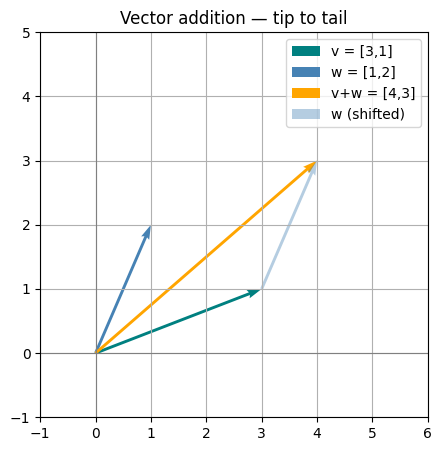

In [4]:
# --- Plot ---
# quiver() draws an arrow: quiver(start_x, start_y, direction_x, direction_y)

plt.figure(figsize=(5, 5))
plt.axhline(0, color='gray', linewidth=0.8)   # x-axis
plt.axvline(0, color='gray', linewidth=0.8)   # y-axis
plt.grid(True)

plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='teal', label='v = [3,1]')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='steelblue', label='w = [1,2]')
plt.quiver(0, 0, (v+w)[0], (v+w)[1], angles='xy', scale_units='xy', scale=1, color='orange', label='v+w = [4,3]')

# tip-to-tail: w starting from the tip of v
plt.quiver(v[0], v[1], w[0], w[1], angles='xy', scale_units='xy', scale=1,
           color='steelblue', alpha=0.4, label='w (shifted)')

plt.xlim(-1, 6)
plt.ylim(-1, 5)
plt.legend()
plt.title('Vector addition — tip to tail')
plt.show()

---
## 2 · Basis Vectors

In [5]:
# --- NumPy ---
i_hat = np.array([1, 0])
j_hat = np.array([0, 1])

# Any vector is just a combination of i_hat and j_hat
v = 3 * i_hat + 2 * j_hat
print('3 * i_hat + 2 * j_hat =', v)

3 * i_hat + 2 * j_hat = [3 2]


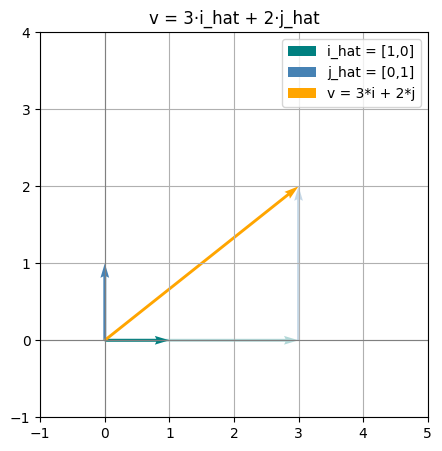

In [6]:
# --- Plot ---
plt.figure(figsize=(5, 5))
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(True)

plt.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color='teal', label='i_hat = [1,0]')
plt.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color='steelblue', label='j_hat = [0,1]')

# show the 3 steps along i, then 2 steps along j
plt.quiver(0, 0, 3, 0, angles='xy', scale_units='xy', scale=1, color='teal', alpha=0.3)
plt.quiver(3, 0, 0, 2, angles='xy', scale_units='xy', scale=1, color='steelblue', alpha=0.3)

# the final vector
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='orange', label='v = 3*i + 2*j')

plt.xlim(-1, 5)
plt.ylim(-1, 4)
plt.legend()
plt.title('v = 3·i_hat + 2·j_hat')
plt.show()

---
## 3 · Linear Transformations

In [7]:
# --- NumPy ---
R = np.array([[0, -1],    # 90° counter clockwise rotation
              [1,  0]])

S = np.array([[1, 1],     # shear
              [0, 1]])

v = np.array([3, 1])

print('Original v  :', v)
print('Rotated  R@v:', R @ v)
print('Sheared  S@v:', S @ v)

Original v  : [3 1]
Rotated  R@v: [-1  3]
Sheared  S@v: [4 1]


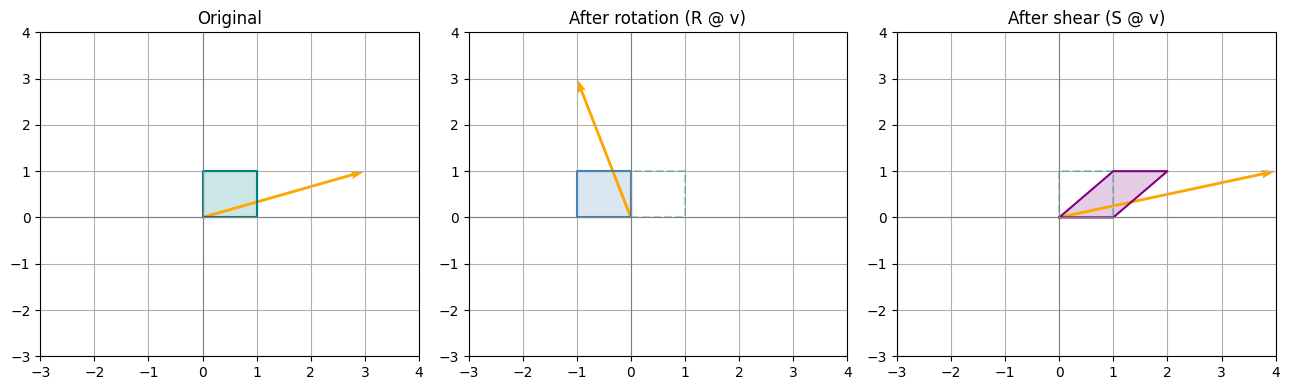

In [8]:
# --- Plot ---
# We'll show how the unit square gets warped by each matrix
# The unit square corners: (0,0) (1,0) (1,1) (0,1)

square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

square_R = R @ square    # rotated square
square_S = S @ square    # sheared square

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Original
axes[0].plot(square[0], square[1], 'teal')
axes[0].fill(square[0], square[1], alpha=0.2, color='teal')
axes[0].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='orange')
axes[0].set_xlim(-3, 4); 
axes[0].set_ylim(-3, 4)
axes[0].axhline(0, color='gray', lw=0.8); 
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].grid(True); axes[0].set_title('Original')

# After rotation
axes[1].plot(square[0],   square[1],   'teal',       alpha=0.3, linestyle='--')  # ghost
axes[1].plot(square_R[0], square_R[1], 'steelblue')
axes[1].fill(square_R[0], square_R[1], alpha=0.2, color='steelblue')
axes[1].quiver(0, 0, (R@v)[0], (R@v)[1], angles='xy', scale_units='xy', scale=1, color='orange')
axes[1].set_xlim(-3, 4); 
axes[1].set_ylim(-3, 4)
axes[1].axhline(0, color='gray', lw=0.8); 
axes[1].axvline(0, color='gray', lw=0.8)
axes[1].grid(True); axes[1].set_title('After rotation (R @ v)')

# After shear
axes[2].plot(square[0],   square[1],   'teal',   alpha=0.3, linestyle='--')  # ghost
axes[2].plot(square_S[0], square_S[1], 'purple')
axes[2].fill(square_S[0], square_S[1], alpha=0.2, color='purple')
axes[2].quiver(0, 0, (S@v)[0], (S@v)[1], angles='xy', scale_units='xy', scale=1, color='orange')
axes[2].set_xlim(-3, 4); 
axes[2].set_ylim(-3, 4)
axes[2].axhline(0, color='gray', lw=0.8); 
axes[2].axvline(0, color='gray', lw=0.8)
axes[2].grid(True); axes[2].set_title('After shear (S @ v)')

plt.tight_layout()
plt.show()

---
## 4 · Matrix Multiplication

In [9]:
# --- NumPy ---
R = np.array([[0, -1], [1, 0]])   # rotate counter clockwise
S = np.array([[1,  1], [0, 1]])   # shear
C = R @ S                         # composed: shear first, then rotate

v = np.array([1, 0])

print('Step by step  R @ (S @ v) =', R @ (S @ v))
print('Composed      C @ v       =', C @ v)
print('Same result?', np.allclose(R @ (S @ v), C @ v))

Step by step  R @ (S @ v) = [0 1]
Composed      C @ v       = [0 1]
Same result? True


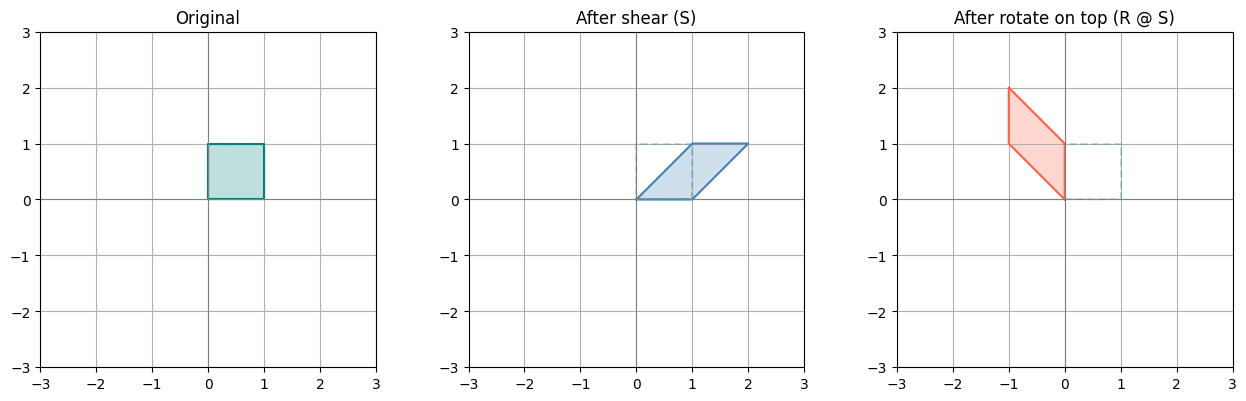

In [10]:
# --- Plot ---
# Show the unit square going through 3 stages: original → sheared → rotated

square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

sq_sheared  = S @ square
sq_composed = C @ square

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

titles = ['Original', 'After shear (S)', 'After rotate on top (R @ S)']
squares = [square, sq_sheared, sq_composed]
colors  = ['teal', 'steelblue', 'tomato']

for ax, sq, color, title in zip(axes, squares, colors, titles):
    # draw original as faint ghost on all panels
    ax.plot(square[0], square[1], 'teal', alpha=0.25, linestyle='--')
    # draw this panel's square
    ax.plot(sq[0], sq[1], color)
    ax.fill(sq[0], sq[1], alpha=0.25, color=color)
    ax.set_xlim(-3, 3); 
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='gray', lw=0.8); 
    ax.axvline(0, color='gray', lw=0.8)
    ax.grid(True); ax.set_title(title)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 5 · Dot Product

In [15]:
# --- NumPy ---
v = np.array([4, 0])
w = np.array([2, 2])

dot   = np.dot(v, w)
#this is the formula for angle between two vectors using the dot product
#np.linalg.norm(v) and np.linalg.norm(w) compute the lengths (magnitudes) of v and w.
#dot / (np.linalg.norm(v) * np.linalg.norm(w)) gives the cosine of the angle between the vectors (from the dot product formula).
#np.arccos(...) computes the angle in radians whose cosine is that value.
#np.degrees(...) converts the angle from radians to degrees.
angle = np.degrees(np.arccos(dot / (np.linalg.norm(v) * np.linalg.norm(w))))
print(angle)
print('dot product  :', dot)
print('angle        :', round(angle, 2), 'degrees')
print('perpendicular?', np.isclose(dot, 0))

45.00000000000001
dot product  : 8
angle        : 45.0 degrees
perpendicular? False


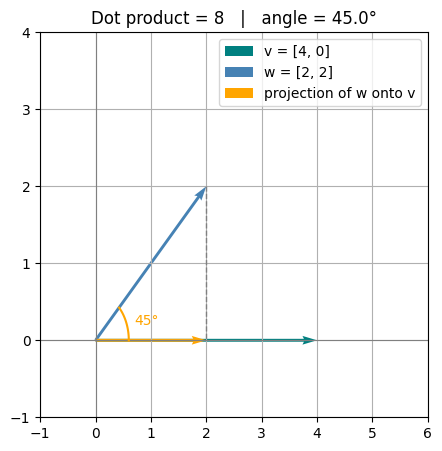

In [18]:
# --- Plot ---
# Show v, w, and the projection of w onto v

# Compute the projection of vector w onto vector v:
# 1. np.dot(w, v): dot product of w and v (measures how much w points in the direction of v)
# 2. np.dot(v, v): dot product of v with itself (the squared length of v)
# 3. The ratio gives the scalar component of w in the direction of v
# 4. Multiplying by v gives the projection vector (the 'shadow' of w onto v)
proj = (np.dot(w, v) / np.dot(v, v)) * v   # projection of w onto v

plt.figure(figsize=(5, 5))
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(True)

plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='teal',      label=f'v = {v.tolist()}')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='steelblue', label=f'w = {w.tolist()}')
plt.quiver(0, 0, proj[0], proj[1], angles='xy', scale_units='xy', scale=1, color='orange', label='projection of w onto v')

# dashed drop line from w tip to its projection
plt.plot([w[0], proj[0]], [w[1], proj[1]], 'gray', linestyle='--', linewidth=1)

# angle arc
# as the angle is in degrees, we convert it to radians for the trigonometric functions
# with linspace, we create an array of angles from 0 to the angle between v and w, which will be used to draw the arc representing the angle.
theta = np.linspace(0, np.radians(angle), 40)
# 0.6 * np.cos(theta) and 0.6 * np.sin(theta) compute the x and y coordinates of points along a circle of radius 0.6
plt.plot(0.6 * np.cos(theta), 0.6 * np.sin(theta), 'orange', linewidth=1.5)
plt.text(0.7, 0.2, f'{angle:.0f}°', color='orange', fontsize=10)

plt.xlim(-1, 6)
plt.ylim(-1, 4)
plt.legend()
plt.title(f'Dot product = {dot}   |   angle = {angle:.1f}°')
plt.show()

---
## 6 · Determinant

In [23]:
# --- NumPy ---
M_scale   = np.array([[2., 0.], [0., 1.]])   # stretches x → det = 2
M_rotate  = np.array([[0.,-1.], [1., 0.]])   # rotation  → det = 1
M_singular= np.array([[1., 2.], [0., 0.]])   # collapses → det = 0
M_flip    = np.array([[-1.,0.], [0., 1.]])   # flips     → det = -1

for name, M in [('Scale', M_scale), ('Rotate', M_rotate),
                ('Singular', M_singular), ('Flip', M_flip)]:
    print(f'{name:10s}  det = {np.linalg.det(M):.1f}')

Scale       det = 2.0
Rotate      det = 1.0
Singular    det = 0.0
Flip        det = -1.0


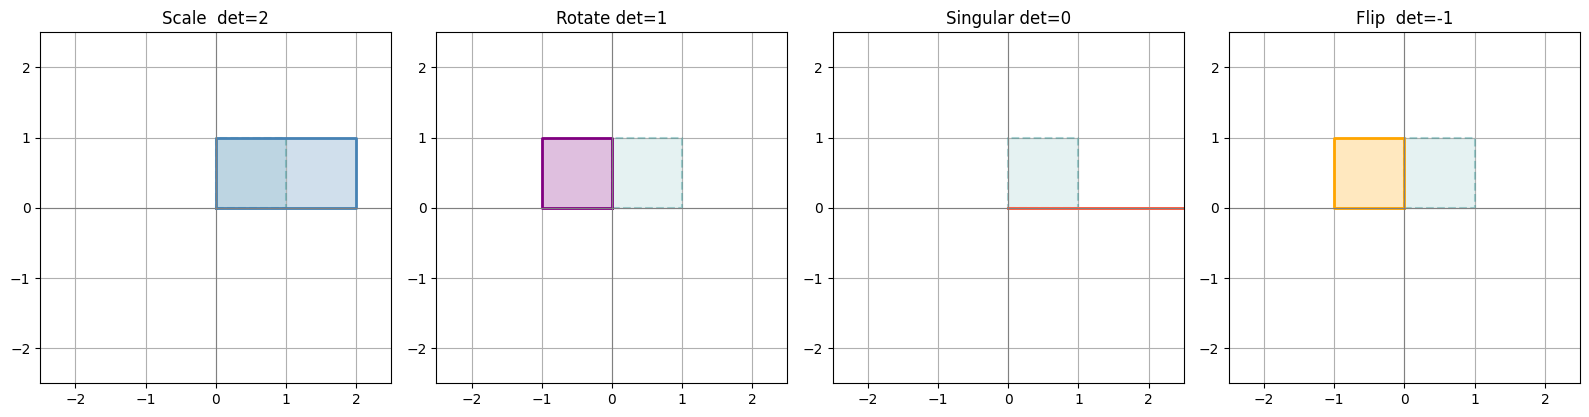

In [26]:
# --- Plot ---
# Show how each matrix warps the unit square

square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

matrices = [
    ('Scale  det=2',   M_scale,    'steelblue'),
    ('Rotate det=1',   M_rotate,   'purple'),
    ('Singular det=0', M_singular, 'tomato'),
    ('Flip  det=-1',   M_flip,     'orange'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (title, M, color) in zip(axes, matrices):
    sq_t = M @ square
    # original ghost
    ax.plot(square[0], square[1], 'teal', alpha=0.3, linestyle='--', label='original')
    ax.fill(square[0], square[1], color='teal', alpha=0.1)
    # transformed
    ax.plot(sq_t[0], sq_t[1], color, linewidth=2)
    ax.fill(sq_t[0], sq_t[1], color=color, alpha=0.25)
    ax.set_xlim(-2.5, 2.5); 
    ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color='gray', lw=0.8); 
    ax.axvline(0, color='gray', lw=0.8)
    ax.grid(True); 
    ax.set_title(title); 
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 7 · Eigenvectors

In [30]:
# --- NumPy ---
M = np.array([[3., 1.],
              [0., 2.]])

vals, vecs = np.linalg.eig(M)

print('Eigenvalues :', vals)
print('Eigenvectors (as columns):')
print(vecs.round(3))

# Verify M @ e == lambda * e
for i in range(len(vals)):
    e = vecs[:, i]
    print(f'  M @ e{i+1} == {vals[i]:.0f} * e{i+1}  →', np.allclose(M @ e, vals[i] * e))

Eigenvalues : [3. 2.]
Eigenvectors (as columns):
[[ 1.    -0.707]
 [ 0.     0.707]]
  M @ e1 == 3 * e1  → True
  M @ e2 == 2 * e2  → True


[1. 0.]
[-0.70710678  0.70710678]


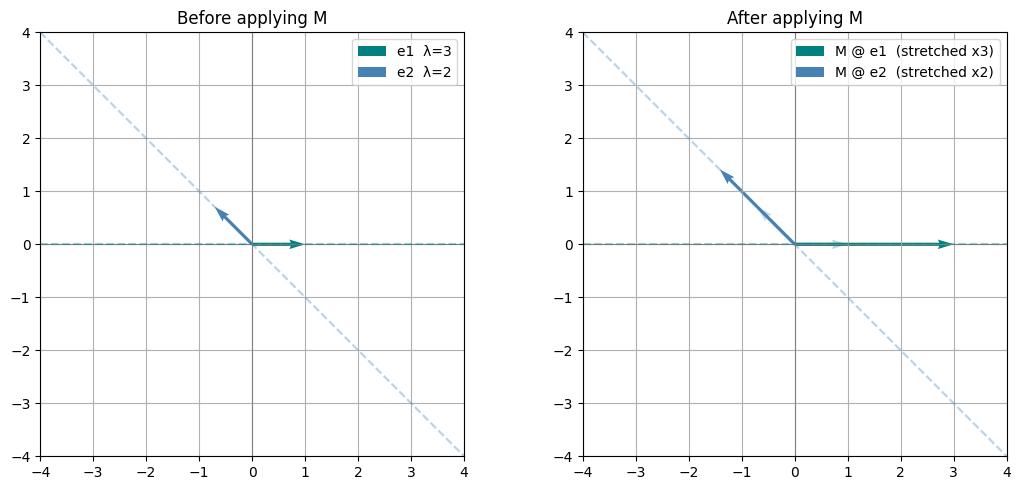

In [34]:
# --- Plot ---
# Left panel:  eigenvectors before applying M
# Right panel: eigenvectors after applying M  (they only stretched, never rotated)

e1 = vecs[:, 0]   # first eigenvector
e2 = vecs[:, 1]   # second eigenvector
print(e1)
print(e2)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, title in zip(axes, ['Before applying M', 'After applying M']):
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(0, color='gray', lw=0.8)
    ax.grid(True)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal'); ax.set_title(title)

    # dashed span lines show the invariant directions
    t = np.linspace(-4, 4, 2)
    if abs(e1[0]) > 1e-9:
        axes[0].plot(t, t * e1[1]/e1[0], 'teal',      alpha=0.2, linestyle='--')
        axes[1].plot(t, t * e1[1]/e1[0], 'teal',      alpha=0.2, linestyle='--')
    if abs(e2[0]) > 1e-9:
        axes[0].plot(t, t * e2[1]/e2[0], 'steelblue', alpha=0.2, linestyle='--')
        axes[1].plot(t, t * e2[1]/e2[0], 'steelblue', alpha=0.2, linestyle='--')

# Before: draw eigenvectors at their original length
axes[0].quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1, color='teal',      label=f'e1  λ={vals[0]:.0f}')
axes[0].quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1, color='steelblue', label=f'e2  λ={vals[1]:.0f}')

# After: draw M @ eigenvector  (same direction, scaled by eigenvalue)
axes[1].quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1, color='teal',      alpha=0.3, linestyle='dashed')
axes[1].quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1, color='steelblue', alpha=0.3, linestyle='dashed')
axes[1].quiver(0, 0, (M@e1)[0], (M@e1)[1], angles='xy', scale_units='xy', scale=1, color='teal',      label=f'M @ e1  (stretched x{vals[0]:.0f})')
axes[1].quiver(0, 0, (M@e2)[0], (M@e2)[1], angles='xy', scale_units='xy', scale=1, color='steelblue', label=f'M @ e2  (stretched x{vals[1]:.0f})')

axes[0].legend(); 
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 8 · Inverse of a Matrix

The inverse of a square matrix $M$ is a matrix $M^{-1}$ such that $M M^{-1} = I$ (the identity matrix). Not all matrices have an inverse: only those with nonzero determinant (nonsingular matrices) do.

In [35]:
# --- NumPy ---
# Let's calculate the inverse of a 2x2 matrix (if it exists)
M = np.array([[3., 1.],
              [0., 2.]])

print("Matrix M:")
print(M)

# Compute the inverse using np.linalg.inv
if np.linalg.det(M) != 0:
    M_inv = np.linalg.inv(M)
    print("Inverse of M:")
    print(M_inv)
    # Check: M @ M_inv should be the identity matrix
    print("M @ M_inv:")
    print(np.round(M @ M_inv, 3))
else:
    print("Matrix M is singular and does not have an inverse.")

Matrix M:
[[3. 1.]
 [0. 2.]]
Inverse of M:
[[ 0.33333333 -0.16666667]
 [ 0.          0.5       ]]
M @ M_inv:
[[1. 0.]
 [0. 1.]]


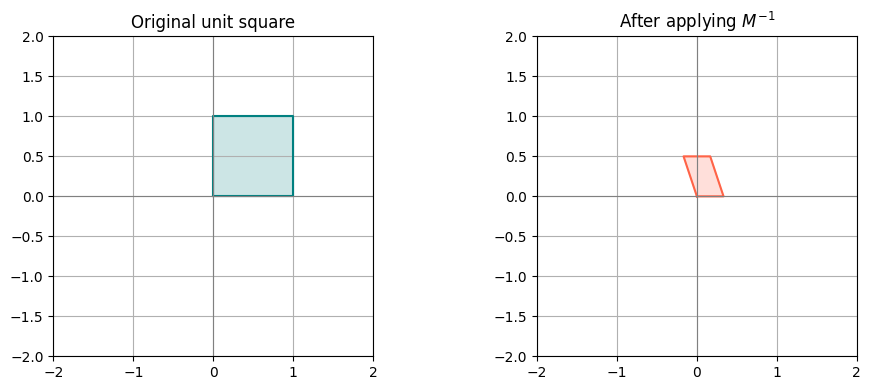

In [36]:
# --- Plot ---
# Show the effect of the inverse matrix on the unit square
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

if np.linalg.det(M) != 0:
    sq_inv = M_inv @ square
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Original square
    axes[0].plot(square[0], square[1], 'teal')
    axes[0].fill(square[0], square[1], alpha=0.2, color='teal')
    axes[0].set_xlim(-2, 2); axes[0].set_ylim(-2, 2)
    axes[0].axhline(0, color='gray', lw=0.8); axes[0].axvline(0, color='gray', lw=0.8)
    axes[0].grid(True); axes[0].set_title('Original unit square')
    axes[0].set_aspect('equal')
    # Transformed by inverse
    axes[1].plot(sq_inv[0], sq_inv[1], 'tomato')
    axes[1].fill(sq_inv[0], sq_inv[1], alpha=0.2, color='tomato')
    axes[1].set_xlim(-2, 2); axes[1].set_ylim(-2, 2)
    axes[1].axhline(0, color='gray', lw=0.8); axes[1].axvline(0, color='gray', lw=0.8)
    axes[1].grid(True); axes[1].set_title('After applying $M^{-1}$')
    axes[1].set_aspect('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Matrix M is singular and does not have an inverse, so no plot.')

---
## 9 · Rank of a Matrix

The rank of a matrix is the maximum number of linearly independent rows or columns. It tells us about the dimension of the space spanned by its rows or columns. For a square matrix, full rank means it is invertible.

In [38]:
# --- NumPy ---
# Calculate the rank of a matrix using np.linalg.matrix_rank
M = np.array([[1., 2., 3.],
              [1., 4., 2. ],
              [2., 6., 5.]])

print("Matrix M:")
print(M)

rank = np.linalg.matrix_rank(M)
print("Rank of M:", rank)

Matrix M:
[[1. 2. 3.]
 [1. 4. 2.]
 [2. 6. 5.]]
Rank of M: 2


---
## 10 · Cross Product (3D only)

The cross product is an operation on two 3D vectors that results in another vector perpendicular to both. Its magnitude equals the area of the parallelogram spanned by the two vectors. The cross product is only defined in three dimensions.

In [39]:
# --- NumPy ---
# Calculate the cross product of two 3D vectors
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("Vector a:", a)
print("Vector b:", b)

cross = np.cross(a, b)
print("Cross product a × b:", cross)

Vector a: [1 2 3]
Vector b: [4 5 6]
Cross product a × b: [-3  6 -3]
